# Principal Portfolios

This notebook showcases the implementation of the model from

> Kelly, Bryan T., Semyon Malamud, and Lasse Heje Pedersen (2023), ["Principal Portfolios"](https://doi.org/10.1111/jofi.13199), *The Journal of Finance*, 78(1), 347-387.

The framework generalizes the standard way of turning a predictive signal into a trading strategy. Instead of using each asset's signal only to trade that same asset, it uses **every asset's signal to predict every asset's return**, including cross-predictability. All the information relevant for linear strategies is summarized in a single object, the **prediction matrix**, and the optimal strategies turn out to be its singular vectors, which the authors call **principal portfolios**.

In [1]:
from empfin import (
    PrincipalPortfolios,
    PrincipalPortfoliosBacktest,
    momentum_signal,
    ff25p,
)

## The Framework

At each date $t$ we observe a vector of signals $S_t$ for $N$ assets with excess returns $R_{t+1}$. A **linear strategy** is characterized by an $N \times N$ matrix $L$ that maps signals into positions,

$$
w_t = L S_t
$$

and earns $w_t' R_{t+1}$. The **simple (own-signal) factor** is the special case $L = I$: each asset is held in proportion to its own signal, earning $S_t' R_{t+1}$. This is how classical characteristic-sorted factors (momentum, value, etc.) are built.

The expected return of any linear strategy depends on the joint distribution of signals and returns only through the **prediction matrix**

$$
\Pi = E\left[ R_{t+1} S_t' \right]
\qquad \Rightarrow \qquad
E\left[ w_t' R_{t+1} \right] = \text{tr}(L' \Pi)
$$

The $(i,j)$ entry of $\Pi$ measures how much the signal of asset $j$ predicts the return of asset $i$. The diagonal is the own-signal predictability exploited by the simple factor; the off-diagonal elements are cross-predictability, which the simple factor ignores.

### Principal Portfolios (PP)

The optimal strategy, subject to a unit bound on the largest singular value of $L$ (a leverage constraint), comes from the singular value decomposition $\Pi = \sum_k \sigma_k u_k v_k'$:

$$
L^* = \sum_k u_k v_k'
\qquad \Rightarrow \qquad
w_t^* = \sum_k \left(v_k' S_t\right) u_k
$$

The optimal strategy is a sum of **principal portfolios**: the $k$-th PP holds the fixed portfolio $u_k$, scaled over time by the timing signal $v_k' S_t$,

$$
PP_{k,t+1} = \left(S_t' v_k\right)\left(u_k' R_{t+1}\right), \qquad E\left[PP_k\right] = \sigma_k
$$

### Beta and Alpha: PEPs and PAPs

Decomposing the prediction matrix into its symmetric and antisymmetric parts, $\Pi = \Pi_s + \Pi_a$ with $\Pi_s = \tfrac{1}{2}(\Pi + \Pi')$ and $\Pi_a = \tfrac{1}{2}(\Pi - \Pi')$, splits the problem into exposure (beta) and alpha:

- **Principal Exposure Portfolios (PEP).** From the eigendecomposition $\Pi_s = \sum_k \lambda_k w_k w_k'$ (eigenvalues in decreasing order),

$$
PEP_{k,t+1} = \left(S_t' w_k\right)\left(w_k' R_{t+1}\right), \qquad E\left[PEP_k\right] = \lambda_k
$$

  These are factor-exposure strategies. Since the $w_k$ form an orthonormal basis, the simple factor is exactly the sum of all the PEPs. Under the null that signals predict returns only through factor risk exposure (no alpha), $\Pi_s$ is positive semidefinite — so **negative eigenvalues are evidence of mispricing**, and the corresponding PEPs are profitable when held short.

- **Principal Alpha Portfolios (PAP).** The antisymmetric part has purely imaginary eigenvalue pairs $\pm i\lambda_k$ and admits the real canonical form $\Pi_a = \sum_k \lambda_k (x_k y_k' - y_k x_k')$ with $\lambda_k > 0$ and $\{x_k, y_k\}$ orthonormal, giving

$$
PAP_{k,t+1} = \left(S_t' y_k\right)\left(x_k' R_{t+1}\right) - \left(S_t' x_k\right)\left(y_k' R_{t+1}\right), \qquad E\left[PAP_k\right] = 2\lambda_k
$$

  Each PAP buys portfolio $x_k$ based on the signal of portfolio $y_k$ and symmetrically shorts $y_k$ based on the signal of $x_k$ — a pure cross-predictability trade. Under the model's null the PAPs have **zero factor exposure**, so any nonzero $\Pi_a$ is direct evidence of alpha.

In sample, the expected return identities above hold *exactly*, which we verify below.

## Data and Signal

We use the Fama-French 25 size/book-to-market double-sorted portfolios (in excess returns) as base assets, and a standard **momentum signal**: each portfolio's cumulative return over the previous 12 months. The class handles the signal timing internally — the signal dated $t$ is only paired with the return of $t+1$, so no look-ahead is involved.

Following the paper, signals are cross-sectionally **rank-transformed** at each date, mapping them to equally spaced values in $[-0.5, 0.5]$. This makes the signal vector dollar-neutral and insensitive to outliers (this is the default `signal_transform="rank"`; z-scored or raw signals are also available).

In [2]:
ports = ff25p()
mom = momentum_signal(ports, lookback=12, skip=0)
ports.tail()

,ME1 BM1,ME1 BM2,ME1 BM3,ME1 BM4,ME1 BM5,ME2 BM1,ME2 BM2,ME2 BM3,ME2 BM4,ME2 BM5,...,ME4 BM1,ME4 BM2,ME4 BM3,ME4 BM4,ME4 BM5,ME5 BM1,ME5 BM2,ME5 BM3,ME5 BM4,ME5 BM5
Date,,,,,,,,,,,,,,,,,,,,,
2025-04-30,0.4568,1.3403,0.5444,-0.9842,-2.8751,0.2469,-1.2547,-2.8043,-3.4868,-6.7272,...,-1.2266,-1.6199,-2.3646,-4.2776,-7.6168,1.0606,-3.3629,-7.7367,-1.6972,-3.1441
2025-05-31,10.4649,5.3824,4.9631,3.8679,5.3372,4.0805,4.7000,6.5733,4.6892,5.4768,...,5.8777,4.6422,3.1553,7.7375,6.2026,7.4277,5.7496,1.4607,2.2356,6.1884
2025-06-30,13.5179,5.5405,8.3003,4.3425,5.1947,5.8885,6.2943,7.0162,5.2760,4.6904,...,1.6951,3.9792,2.0775,7.0415,5.4624,5.1879,5.9051,4.4005,3.3024,6.6709
2025-07-31,1.0927,5.3868,0.2366,1.9500,0.4535,1.4286,1.4293,2.2281,0.5769,1.4453,...,3.0806,1.8366,0.5613,-0.4469,-2.2703,2.9549,1.0668,0.8824,-0.1067,-1.7144
2025-08-31,8.5489,8.5346,9.2586,8.8495,9.5721,8.8509,5.0113,8.1779,8.0105,10.3466,...,3.2724,1.2364,1.9681,5.5048,6.7542,0.7810,0.8127,2.6767,5.0457,8.6999


## Full-Sample Estimation

The `PrincipalPortfolios` class estimates the prediction matrix over the full sample,

$$
\hat{\Pi} = \frac{1}{T} \sum_{t} R_{t+1} S_t'
$$

computes all three decompositions, and stores the portfolio weights and the in-sample return timeseries of every component.

In [3]:
pp = PrincipalPortfolios(
    returns=ports,
    signals=mom,
)
print(f"Sample: {pp.T} months, {pp.N} assets")

Sample: 734 months, 25 assets


The `Pi` attribute holds the estimated prediction matrix. The heatmap below shows it: rows are the return leg, columns are the signal leg. A strong positive diagonal band would mean returns are mostly predicted by the asset's own signal; the off-diagonal structure is the cross-predictability that principal portfolios exploit.

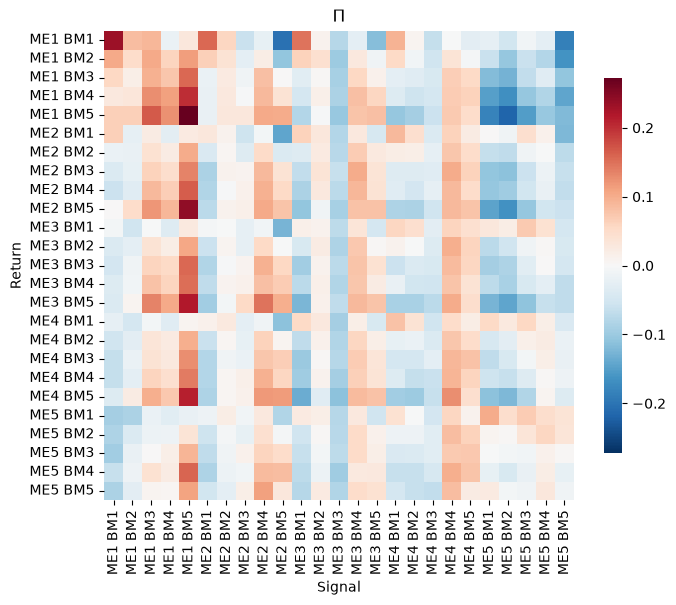

In [4]:
pp.plot_prediction_matrix(which="full")

The antisymmetric part isolates the purely cross-predictive component — everything in this matrix is alpha under the model's null.

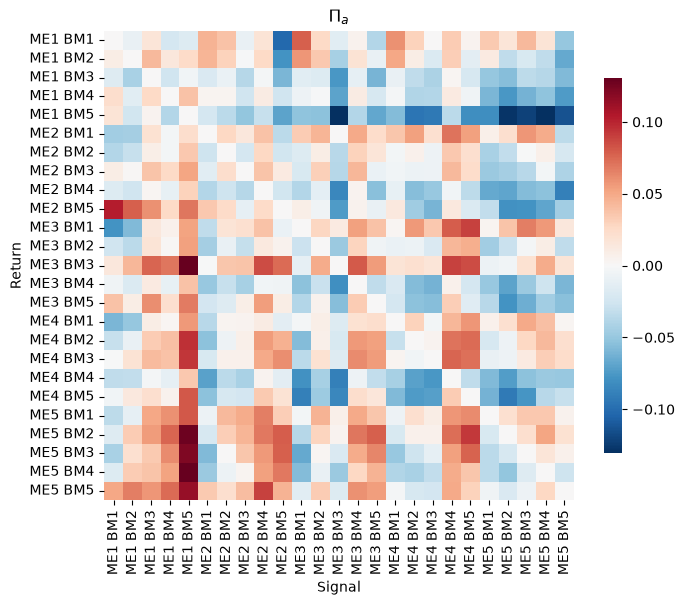

In [5]:
pp.plot_prediction_matrix(which="antisymmetric")

### The Spectrum

The singular values of $\hat{\Pi}$ and the eigenvalues of its symmetry components are the in-sample expected returns of the principal portfolios. Note in the middle panel that several eigenvalues of $\Pi_s$ are **negative** (highlighted): the no-alpha null requires $\Pi_s$ to be positive semidefinite, so these are evidence of mispricing — those PEPs are profitable when shorted. Similarly, the nonzero pair magnitudes of $\Pi_a$ in the right panel are pure-alpha PAP strategies.

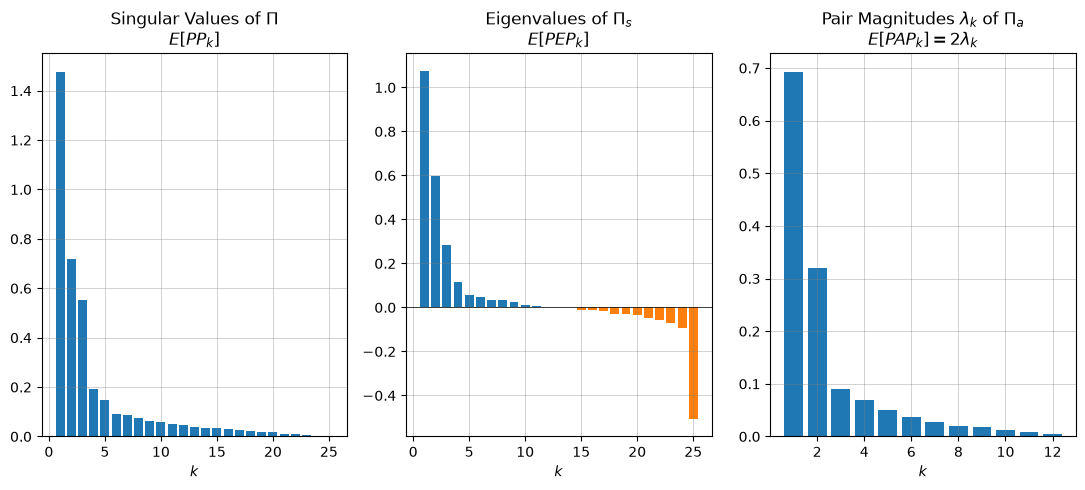

In [6]:
pp.plot_spectrum()

### Expected Return Identities

In sample, the mean return of each component equals exactly its singular value / eigenvalue ($2\lambda_k$ for the PAPs):

In [7]:
import pandas as pd

check = pd.DataFrame({
    "Mean PP": pp.pp_returns.mean().head(4).values,
    "Singular Value": pp.singular_values.head(4).values,
    "Mean PEP": pp.pep_returns.mean().head(4).values,
    "Eigenvalue": pp.pep_eigenvalues.head(4).values,
    "Mean PAP": pp.pap_returns.mean().head(4).values,
    "2 x Lambda": 2 * pp.pap_eigenvalues.head(4).values,
}, index=[f"k = {k}" for k in range(1, 5)])
check.round(4)

,Mean PP,Singular Value,Mean PEP,Eigenvalue,Mean PAP,2 x Lambda
k = 1,1.4774,1.4774,1.0759,1.0759,1.3866,1.3866
k = 2,0.7189,0.7189,0.5980,0.5980,0.6418,0.6418
k = 3,0.5507,0.5507,0.2841,0.2841,0.1809,0.1809
k = 4,0.1903,0.1903,0.1141,0.1141,0.1370,0.1370


And the simple own-signal momentum factor is exactly the sum of all 25 PEPs:

In [8]:
diff = (pp.simple_returns - pp.pep_returns.sum(axis=1)).abs().max()
print(f"Max abs difference between simple factor and sum of PEPs: {diff:.2e}")

Max abs difference between simple factor and sum of PEPs: 1.28e-13


### Portfolio Weights and the Linear Rule

The weight vectors of every component are stored as DataFrames (`pp_positions`, `pp_timing`, `pep_weights`, `pap_x`, `pap_y`). The full linear rule $L$ of an optimal strategy — the matrix mapping the signal vector into positions, $w_t = L S_t$ — is available through `linear_rule`. For example, the rule of the first principal alpha portfolio (a corner of it shown below) says how to trade each asset based on every other asset's momentum:

In [9]:
pp.linear_rule(kind="pap", n_components=1).round(3).iloc[:5, :5]

,ME1 BM1,ME1 BM2,ME1 BM3,ME1 BM4,ME1 BM5
ME1 BM1,0.000,-0.004,-0.019,-0.013,-0.043
ME1 BM2,0.004,0.000,0.007,0.000,0.016
ME1 BM3,0.019,-0.007,0.000,-0.023,-0.000
ME1 BM4,0.013,-0.000,0.023,0.000,0.052
ME1 BM5,0.043,-0.016,0.000,-0.052,0.000


### Alphas and Betas In Sample

The economic content of the symmetry split: PEPs are exposure strategies, while PAPs should carry little exposure to the factor itself. Regressing each component on the simple momentum factor shows the split — the PEPs load heavily on the factor, while the PAP betas are small and their means survive as alphas. The table also includes the last PEPs held short (the negative-eigenvalue strategies).

In [10]:
pp.factor_regressions(n_components=2).round(3)

,Mean,Alpha,t(Alpha),Beta Simple Factor,R2
PP 1,1.477,1.026,1.972,0.327,0.051
PEP 1,1.076,0.754,2.340,0.233,0.066
PP 2,0.719,-0.261,-1.215,0.709,0.596
PEP 2,0.598,-0.368,-2.137,0.700,0.690
Short PEP 25,0.507,0.421,2.746,0.063,0.022
Short PEP 24,0.096,0.183,5.959,-0.063,0.364
PAP 1,1.387,1.018,2.008,0.267,0.036
PAP 2,0.642,0.553,2.340,0.064,0.010


### In-Sample Cumulative Returns

The strategies have very different scales (each is normalized by its unit-norm weight vectors, not by volatility), so we plot them scaled to unit full-sample volatility to compare their risk-adjusted paths.

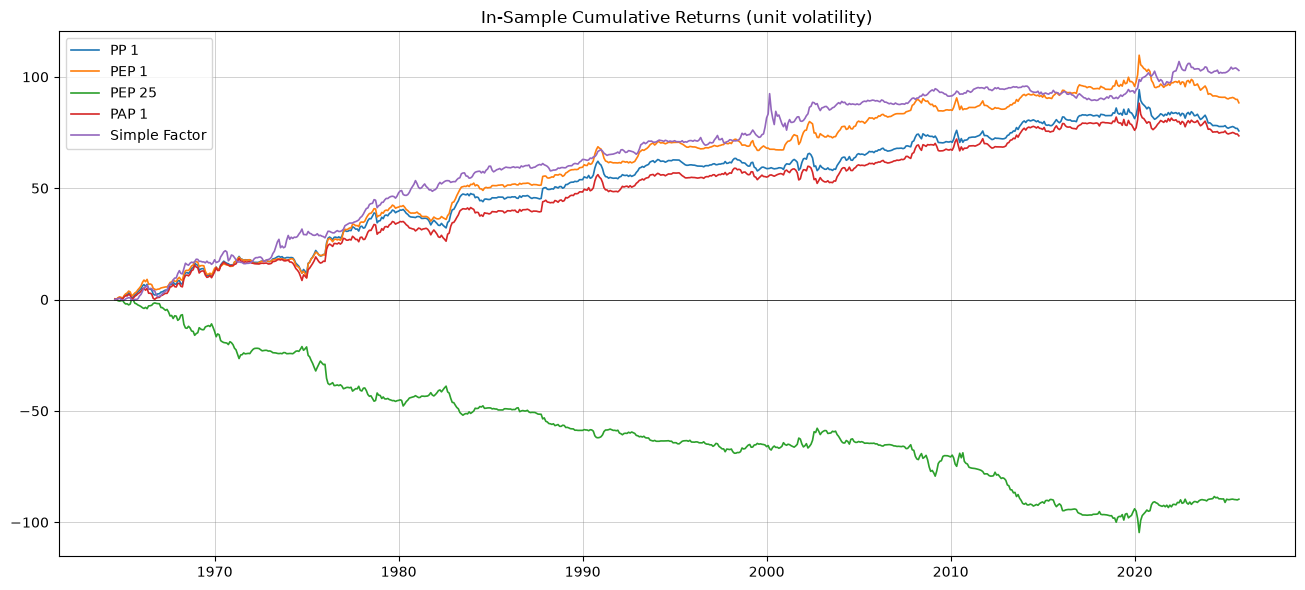

In [11]:
pp.plot_cumulative_returns(unit_vol=True, title="In-Sample Cumulative Returns (unit volatility)")

## Out-of-Sample Backtest

In-sample means are guaranteed to match the eigenvalues, so the real test is out of sample. Following the paper, `PrincipalPortfoliosBacktest` re-estimates the prediction matrix at each date using only a trailing window (120 months here), computes the decompositions, and applies the resulting weights to the *next* month's returns. Every return below is therefore fully out of sample.

One caveat on interpretation: the components are re-ranked at every estimation date, so the column "PEP 2" tracks *whichever* portfolio has the second-largest eigenvalue at each date, not a fixed portfolio.

In [12]:
bt = PrincipalPortfoliosBacktest(
    returns=ports,
    signals=mom,
    window=120,
)
print(f"Out-of-sample months: {bt.T_oos}")

Rolling estimation:   0%|          | 0/614 [00:00<?, ?it/s]

Rolling estimation:  25%|██▌       | 155/614 [00:00<00:00, 1547.33it/s]

Rolling estimation:  52%|█████▏    | 317/614 [00:00<00:00, 1582.86it/s]

Rolling estimation:  78%|███████▊  | 480/614 [00:00<00:00, 1602.48it/s]

Rolling estimation: 100%|██████████| 614/614 [00:00<00:00, 1597.17it/s]

Out-of-sample months: 614


### Performance Summary

Annualized mean, volatility and Sharpe ratio of the leading components, plus their alphas and betas with respect to the simple momentum factor. As predicted by the theory, the PAPs (and the short positions in the negative-eigenvalue PEPs) have small betas to the factor — their returns are alpha.

In [13]:
bt.performance_summary(n_components=3).round(3)

,Mean,Vol,Sharpe,Alpha,t(Alpha),Beta Simple Factor,R2
Simple Factor,14.366,33.793,0.425,NaN,NaN,NaN,NaN
PP 1,5.555,58.491,0.095,0.223,0.326,0.201,0.013
PEP 1,4.280,35.652,0.120,-0.129,-0.334,0.406,0.148
PP 2,12.055,20.311,0.594,0.650,3.130,0.296,0.243
PEP 2,10.540,20.099,0.524,0.559,2.649,0.267,0.201
PP 3,1.634,10.030,0.163,0.038,0.334,0.082,0.077
PEP 3,-0.840,7.339,-0.114,-0.125,-1.490,0.046,0.046
Short PEP 25,1.665,25.494,0.065,0.248,0.836,-0.092,0.015
Short PEP 24,0.290,6.169,0.047,0.098,1.439,-0.062,0.115
Short PEP 23,-0.521,2.167,-0.241,-0.029,-1.171,-0.012,0.034


We can also pass additional factors to the alpha regressions. For example, controlling for the Fama-French five factors:

In [14]:
from empfin import ff5f

ff_factors, _ = ff5f()
bt.performance_summary(n_components=2, factors=ff_factors).round(3)

,Mean,Vol,Sharpe,Alpha,t(Alpha),Beta Simple Factor,Beta Mkt-RF,Beta SMB,Beta HML,Beta RMW,Beta CMA,R2
Simple Factor,14.366,33.793,0.425,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PP 1,5.555,58.491,0.095,0.379,0.536,0.177,-0.374,0.102,-0.996,0.674,0.652,0.048
PEP 1,4.280,35.652,0.120,0.012,0.029,0.373,-0.103,0.082,-0.580,-0.004,0.416,0.166
PP 2,12.055,20.311,0.594,0.580,2.676,0.307,0.013,-0.134,0.082,0.056,0.130,0.256
PEP 2,10.540,20.099,0.524,0.430,2.021,0.305,-0.076,-0.128,0.180,0.470,-0.122,0.267
Short PEP 25,1.665,25.494,0.065,0.283,0.922,-0.097,-0.179,0.018,-0.375,0.364,0.312,0.054
Short PEP 24,0.290,6.169,0.047,0.089,1.240,-0.057,-0.004,0.012,0.007,0.064,-0.065,0.124
PAP 1,8.847,57.250,0.155,0.611,0.881,0.134,-0.256,-0.033,-1.037,0.598,0.916,0.041
PAP 2,4.564,17.663,0.258,0.132,0.628,0.137,-0.023,0.081,0.015,0.335,-0.081,0.076


### Out-of-Sample Cumulative Returns

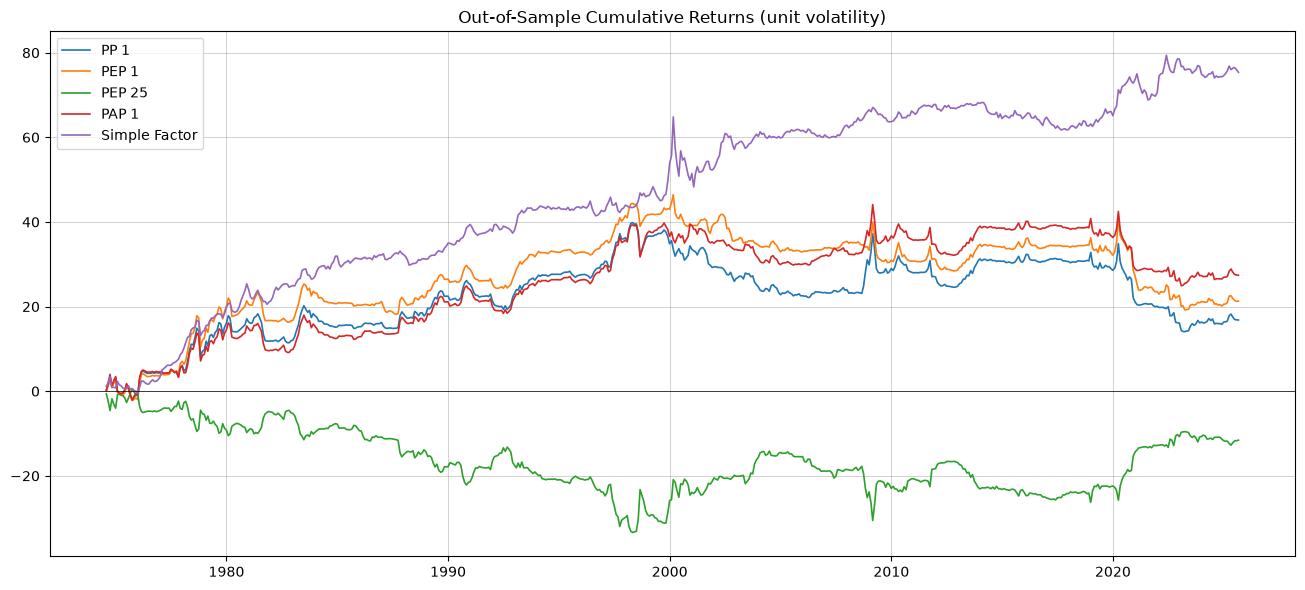

In [15]:
bt.plot_cumulative_returns(
    unit_vol=True,
    title="Out-of-Sample Cumulative Returns (unit volatility)",
)

### Optimal Combined Strategies

`optimal_strategy` combines the leading components of each type into the optimal linear strategy, re-estimated at every date: the sum of the top PPs, the eigenvalue-sign-weighted PEPs, and the sum of the top PAPs.

In [16]:
optimal = pd.concat(
    [
        bt.optimal_strategy("pp", n_components=3),
        bt.optimal_strategy("pep", n_components=3),
        bt.optimal_strategy("pap", n_components=3),
        bt.simple_returns,
    ],
    axis=1,
)

summary = pd.DataFrame({
    "Mean": optimal.mean() * 12,
    "Vol": optimal.std() * (12 ** 0.5),
    "Sharpe": (optimal.mean() / optimal.std()) * (12 ** 0.5),
})
summary.round(3)

,Mean,Vol,Sharpe
Optimal PP (K=3),19.244,58.296,0.330
Optimal PEP (K=3),16.341,58.820,0.278
Optimal PAP (K=3),13.595,54.301,0.250
Simple Factor,14.366,33.793,0.425


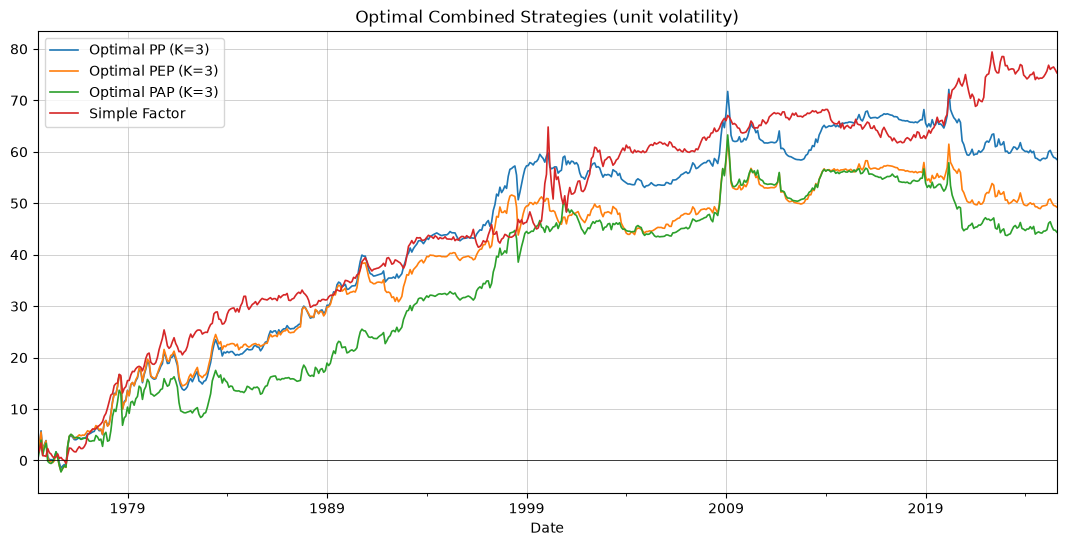

In [17]:
ax = (optimal / optimal.std()).cumsum().plot(
    figsize=(6 * (16 / 7.3), 6),
    lw=1.2,
    title="Optimal Combined Strategies (unit volatility)",
)
ax.axhline(0, color="black", lw=0.5)
ax.yaxis.grid(color="grey", ls="-", lw=0.5, alpha=0.5)
ax.xaxis.grid(color="grey", ls="-", lw=0.5, alpha=0.5)

### The Conditional Spectrum Over Time

The rolling estimates of the singular values and eigenvalues are the model's conditional expected returns for each component. Their variation over time shows how the strength of momentum predictability — and of the embedded alpha — has evolved.

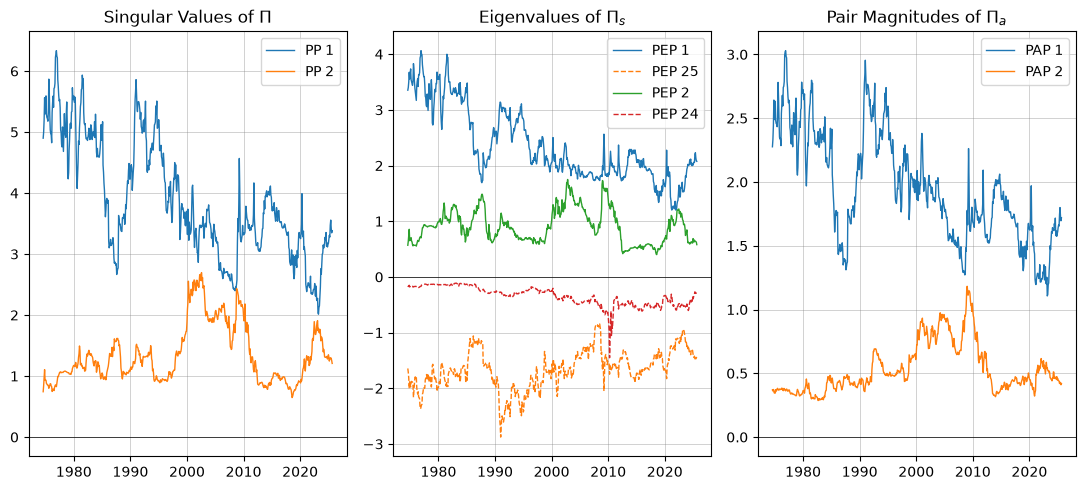

In [18]:
bt.plot_eigenvalues_timeseries(n_components=2)

## References

- Kelly, Bryan T., Semyon Malamud, and Lasse Heje Pedersen (2023), ["Principal Portfolios"](https://doi.org/10.1111/jofi.13199), *The Journal of Finance*, 78(1), 347-387.
- NBER Working Paper version: [w27388](https://www.nber.org/papers/w27388).